<a href="https://colab.research.google.com/github/kjahan/exxon_ocr/blob/main/notebooks/experiment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment I

https://www.wazokucrowd.com/challenges/novel-approaches-to-verify-the-correctness-of-data-extraction-from-scanned-documents/#overview

`The goal of this Challenge, therefore, is to identify objective, measurable criteria allowing us to estimate the correctness of the OCR text and table extraction from scanned documents—and indicate, when appropriate, the need for human verification and correction.`

We envision that a set of characters or signs will be identified signaling that the OCR-processed documents may contain errors (and, ideally, roughly estimate their rate). Possible examples of characters or signs may include:

`1. Visual Clues (scanned source documents):`

`a. Unusual, unrecognizable, and missing (or extra) characters.`
`b. Misspelled or completely unrecognizable words.`
`c. Irregular formatting of the document (variability of font, size, spacing, etc.).`

`2. Content-Related Clues:`

`a. Presumably missing parts of the document.`
`b. Incoherent (difficult to understand or making no sense) text or numeric data.`

`3. Metadata from document analysis results:`

`a. Confidence scores on various levels.`


`Importantly, while we’re interested in any specific character of sign signaling inaccuracy of the OCR text extraction, we’re looking for the solution that will propose an automatic QC process (that is, with only minimal, if at all, human intervention). Ideally, code allowing to execute such a QC check digitally will accompany the proposed solution. Such solutions will receive the greatest attention.`






## Use GPT or an LLM to recover text and then use the delta as error rate estiation for human intervention


Test with the following PDF and JSOn OCR:

`24492351__AMERICAS__Costa-Rica__WELL-LOG__MUDLOGGING__3.43237209320068359375__`


`24492351__AMERICAS__Costa-Rica__WELL-LOG__MUDLOGGING__3.43237209320068359375__.pdf.ocr.json`

Upload above in Google colab manually!

In [1]:
!mkdir data

In [2]:
!pip install --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.61.1
    Uninstalling openai-1.61.1:
      Successfully uninstalled openai-1.61.1


In [6]:
!pip install pdf2image
!apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 20 not upgraded.
Need to get 186 kB of archives.
After this operation, 696 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.6 [186 kB]
Fetched 186 kB in 0s (886 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 124926 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.6_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.6) ...
Setting up poppler-utils (22.02.0-2ubuntu0.6) ...
Processing triggers for man-db (2.10.2-1) ...


In [10]:
import openai
from openai import OpenAI

import getpass
import re
import os
import glob
import time
import pandas as pd
import math
import string
import json
from os import listdir
from os.path import isfile, join

from pdf2image import convert_from_path

# from google.colab import files

## We can also use open source LLMs

In [21]:

try:
    openai.api_key = getpass.getpass()
except Exception as error:
    print('ERROR', error)

MODEL = "gpt-3.5-turbo"
#MODEL = "gpt-4o" #"gpt-4" #"gpt-4-0613"
# MODEL = "o1"


client = OpenAI(
    # defaults to os.environ.get("OPENAI_API_KEY")
    api_key=openai.api_key,
)

··········


## Load pdf for manual review

In [5]:
!ls data

In [8]:
fn = '/content/data/24492351__AMERICAS__Costa-Rica__WELL-LOG__MUDLOGGING__3.43237209320068359375__.pdf'

pages = {}
# Only scan the first k pages
top_pages_to_be_converted=10

pages = convert_from_path(fn, last_page=top_pages_to_be_converted)


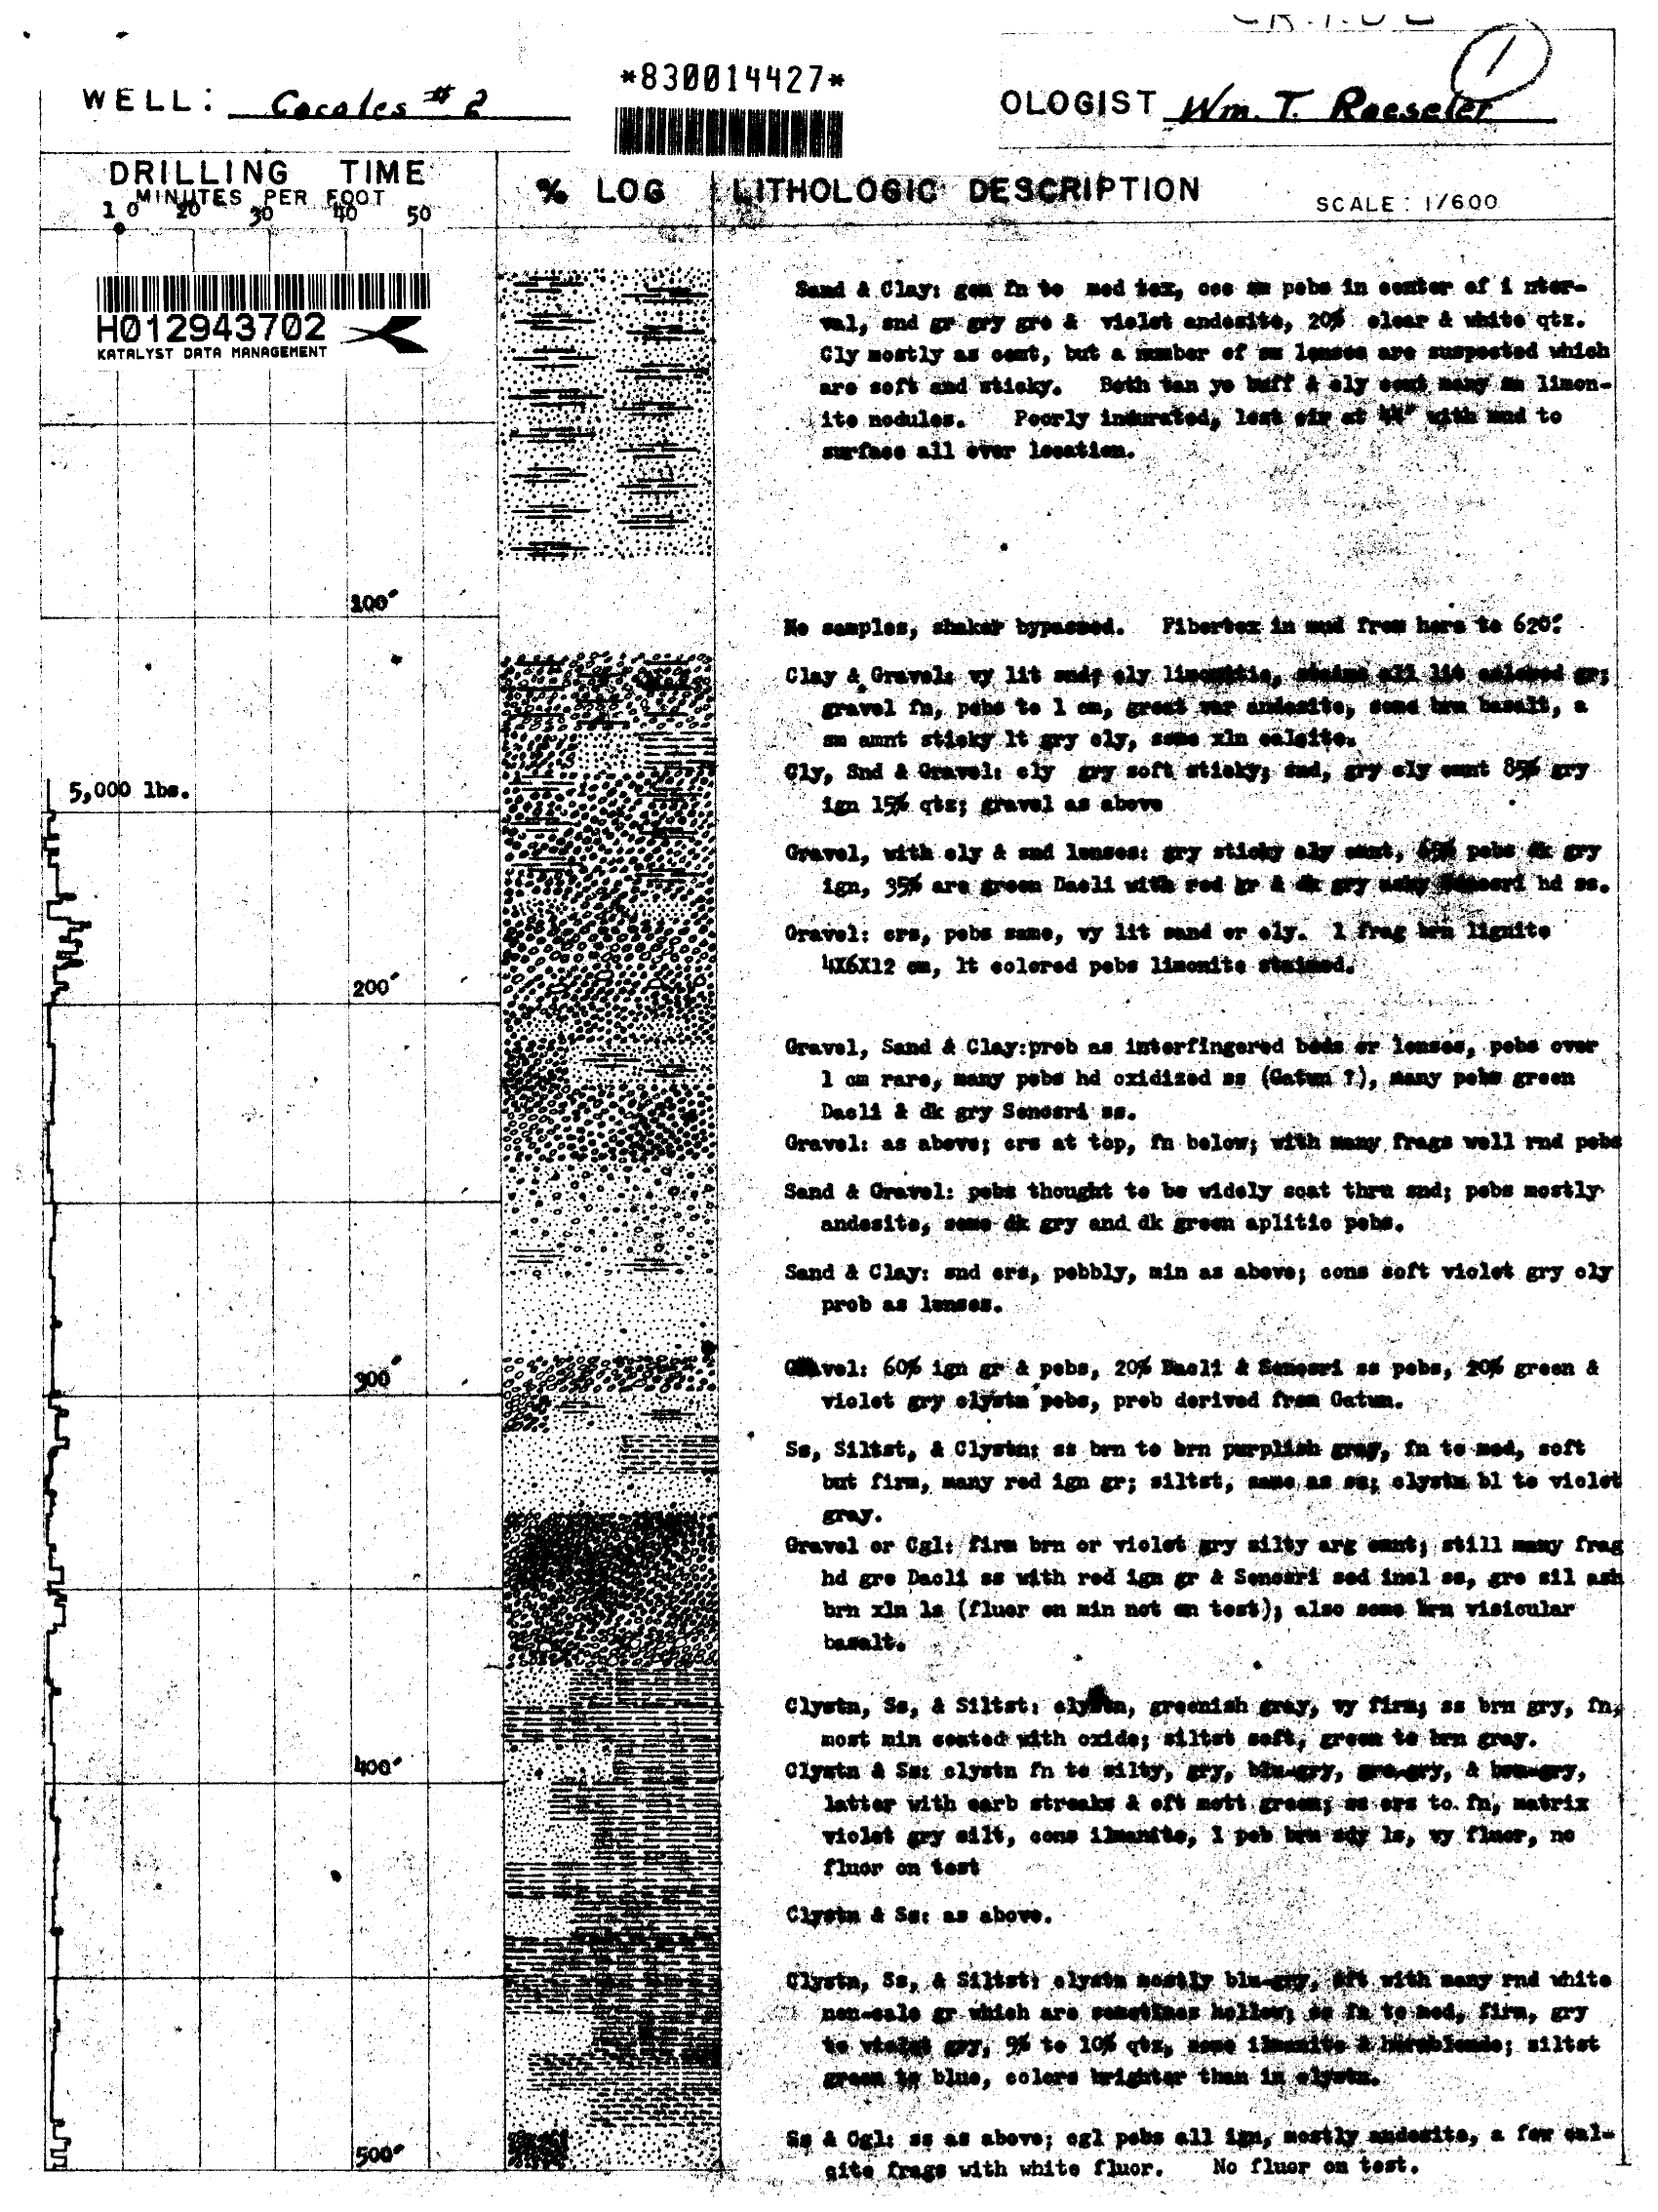

In [9]:
test_inx = 0
pages[test_inx]

## Load OCR json file

In [11]:
ocr_fn = "/content/data/24492351__AMERICAS__Costa-Rica__WELL-LOG__MUDLOGGING__3.43237209320068359375__.pdf.ocr.json"

# Open and read the JSON file
with open(ocr_fn, 'r') as file:
    ocr_data = json.load(file)

In [12]:
ocr_data

{'status': 'succeeded',
 'createdDateTime': '2024-12-07T22:18:38Z',
 'lastUpdatedDateTime': '2024-12-07T22:18:46Z',
 'analyzeResult': {'apiVersion': '2024-07-31-preview',
  'modelId': 'prebuilt-layout',
  'stringIndexType': 'textElements',
  'content': 'WELL:\n\nCorales # 2\n\n\\*830014427\\*\n\nOLOGIST W/m. T. Reeseler\n\n\n<figure>\n\n0\n\n</figure>\n\n\nLITHOLOGIC: DESCRIPTION\n\nSCALE : 1/600\n\nSand & Clays gen in to med tez, oss an pebe in center of\'i nter-\nmal, md gr gry gro & violet endesite, 20%: elmar & white qtz.\nGly mostly as ceut, but a member of om lenses ane suspected which\nare soft and sticky. Beth tan yo burt 4 dây court, my a limon-\nito nodules. Poorly inturated, Lost ein t WN with mad to\nsurface all over location.\n\nNo samples, shaked bypassed. Fibertex in mail from here to 620?\nCủay & Gravels vy Lt mát đây Laossse, (Totm ) 340 chiches ers\ngravel fa, pobe to 1 ca, great var antesšto, sond bin fomuss, a\nsu annt stisky It ary ely, sons xin söleite.\nGly, and 

## Get one paragraph for test

In [20]:
all_text = ocr_data['analyzeResult']['content']
# let's get the text ending with the following pattern in the first page!
pattern = 'from here to 620?'
start_inx = all_text.find(pattern)

test_ocr_text = all_text[:start_inx+len(pattern)]

print(test_ocr_text)


WELL:

Corales # 2

\*830014427\*

OLOGIST W/m. T. Reeseler


<figure>

0

</figure>


LITHOLOGIC: DESCRIPTION

SCALE : 1/600

Sand & Clays gen in to med tez, oss an pebe in center of'i nter-
mal, md gr gry gro & violet endesite, 20%: elmar & white qtz.
Gly mostly as ceut, but a member of om lenses ane suspected which
are soft and sticky. Beth tan yo burt 4 dây court, my a limon-
ito nodules. Poorly inturated, Lost ein t WN with mad to
surface all over location.

No samples, shaked bypassed. Fibertex in mail from here to 620?


## Recover text

In [22]:
def recover_noisy_text(user_text, system_prompt):

  user_prompt = user_text

  start_time = time.time()

  response = client.chat.completions.create(
      model=MODEL,
      messages=[
          {"role": "system", "content": system_prompt},
          {"role": "user", "content": user_prompt}
      ],
      temperature=0.1,
  )
  text = response.choices[0].message.content.strip()
  print(f"Runtime: {round((time.time() - start_time), 2)}")

  return text

## Run test I

In [27]:
system_prompt = "You are a helpful assistant. I'll give you a noisy OCR geoscience text. Your task is to think step by step and use your knowledge in order to reconstruct the original text from the corrupted one. Only return the reconstructed text."


In [28]:
system_prompt

"You are a helpful assistant. I'll give you a noisy OCR geoscience text. Your task is to think step by step and use your knowledge in order to reconstruct the original text from the corrupted one. Only return the reconstructed text."

In [33]:
recovred_text = recover_noisy_text(test_ocr_text, system_prompt)

Runtime: 1.26


In [30]:
test_ocr_text

"WELL:\n\nCorales # 2\n\n\\*830014427\\*\n\nOLOGIST W/m. T. Reeseler\n\n\n<figure>\n\n0\n\n</figure>\n\n\nLITHOLOGIC: DESCRIPTION\n\nSCALE : 1/600\n\nSand & Clays gen in to med tez, oss an pebe in center of'i nter-\nmal, md gr gry gro & violet endesite, 20%: elmar & white qtz.\nGly mostly as ceut, but a member of om lenses ane suspected which\nare soft and sticky. Beth tan yo burt 4 dây court, my a limon-\nito nodules. Poorly inturated, Lost ein t WN with mad to\nsurface all over location.\n\nNo samples, shaked bypassed. Fibertex in mail from here to 620?"

In [32]:
def levenshtein_distance(str1, str2):
    """
    Compute the Levenshtein distance between two strings.

    Args:
        str1: The first string.
        str2: The second string.

    Returns:
        The Levenshtein distance between str1 and str2.
    """
    len_str1 = len(str1)
    len_str2 = len(str2)

    # Initialize a matrix to store distances between prefixes of the strings
    matrix = [[0 for _ in range(len_str2 + 1)] for _ in range(len_str1 + 1)]

    # Fill first row and column
    for i in range(len_str1 + 1):
        matrix[i][0] = i
    for j in range(len_str2 + 1):
        matrix[0][j] = j

    # Calculate distances
    for i in range(1, len_str1 + 1):
        for j in range(1, len_str2 + 1):
            cost = 0 if str1[i - 1] == str2[j - 1] else 1
            matrix[i][j] = min(
                matrix[i - 1][j] + 1,      # Deletion
                matrix[i][j - 1] + 1,      # Insertion
                matrix[i - 1][j - 1] + cost  # Substitution
            )

    return matrix[len_str1][len_str2]

# Example usage
string1 = "kitten"
string2 = "sitting"
distance = levenshtein_distance(string1, string2)
print(f"The Levenshtein distance between '{string1}' and '{string2}' is: {distance}")

string1 = "kitten"
string2 = "kioten"
distance = levenshtein_distance(string1, string2)
print(f"The Levenshtein distance between '{string1}' and '{string2}' is: {distance}")

The Levenshtein distance between 'kitten' and 'sitting' is: 3
The Levenshtein distance between 'kitten' and 'kioten' is: 1


## Compute Levenshtein distance between recocered and original text

In [34]:

distance = levenshtein_distance(recovred_text, test_ocr_text)
print(f"The Levenshtein distance between ocr and recovered is: {distance}")


The Levenshtein distance between ocr and recovered is: 181
